# State-space models and filtering

How to track a continuous latent state evolving in time from noisy observations - the local-level model (random walk + noise) and AR(1)-plus-noise - and the difference between filtering (estimate the state using data up to now, for online/real-time use) and smoothing (use the whole series, for retrospective analysis). This is the continuous-state cousin of the HMM, and the engine is the Kalman filter.


## Linear-Gaussian state-space models and the Kalman filter

A linear-Gaussian state-space model evolves a hidden state and observes a noisy linear function of it,
$$x_t = A x_{t-1} + w_t,\quad w_t\sim\mathcal N(0,Q), \qquad y_t = H x_t + v_t,\quad v_t\sim\mathcal N(0,R),$$
with $x_0\sim\mathcal N(m_0,P_0)$. The filtering problem is to compute $p(x_t\mid y_{1:t})$ online.

Theorem (Kalman filter). For the linear-Gaussian model the filtering distribution is exactly Gaussian,
$p(x_t\mid y_{1:t})=\mathcal N(\hat x_t, P_t)$, given by the recursion
$$\text{predict: } \hat x_t^- = A\hat x_{t-1},\ P_t^- = AP_{t-1}A^\top + Q; \qquad
  \text{update: } K_t = P_t^- H^\top (HP_t^- H^\top + R)^{-1},$$
$\hat x_t = \hat x_t^- + K_t(y_t - H\hat x_t^-)$, $P_t = (I-K_t H)P_t^-$. The Kalman gain $K_t$ weights the
prediction against the new measurement by their relative precisions.

Proof idea. Each step is a conjugate Gaussian update: the prediction propagates a Gaussian through a
linear map plus Gaussian noise (still Gaussian), and the measurement update is Bayes' rule for a Gaussian
prior and Gaussian likelihood (still Gaussian), whose mean and covariance are the stated formulas. By
induction the filtering distribution stays Gaussian for all $t$. $\quad\blacksquare$

Theorem (optimality). Among all estimators, the Kalman filter mean is the minimum-mean-squared-error
estimator $\mathbb E[x_t\mid y_{1:t}]$ for the linear-Gaussian model; among linear estimators it is
optimal for any noise distribution with the given covariances. The RTS smoother extends it to
$p(x_t\mid y_{1:T})$ using all data, with a backward pass.

## Diagnostics and the limits of linearity

A correctly specified filter produces white, unit-variance standardized innovations (the applied section
checks this); autocorrelated or mis-scaled innovations indicate wrong noise levels or a wrong model.

Counterexample (nonlinearity and non-Gaussianity break optimality). The exactness and optimality hold only
for linear dynamics with Gaussian noise. For nonlinear systems the true filtering distribution is not
Gaussian and the Kalman recursions no longer apply; linearizing (the extended Kalman filter) or
sigma-point methods (the unscented Kalman filter) approximate it, and for strongly nonlinear or
multimodal problems a particle filter is needed. Applying the plain Kalman filter to such a system can be
badly biased. We verify the exactness claim for the linear-Gaussian case below by matching the recursive
filter to the batch posterior.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.ppl import LocalLevel, AR1
rng = np.random.RandomState(0)

## 1. The local-level model and the Kalman filter

The local-level model has a hidden level that drifts as a random walk, observed with noise:

$$x_t = x_{t-1} + w_t,\quad w_t\sim\mathcal N(0,q); \qquad y_t = x_t + v_t,\quad v_t\sim\mathcal N(0,r).$$

The Kalman filter tracks the posterior of $x_t$ given $y_{1:t}$ in two repeated steps - predict (push the state forward, variance grows by $q$) then update (correct toward $y_t$, weighted by the Kalman gain $K_t = P/(P+r)$). The gain is the whole story: when observations are reliable ($r$ small) it trusts the data; when noisy, it trusts the model. We implement the filter in a few lines to see it, then use mixle's fitted model.


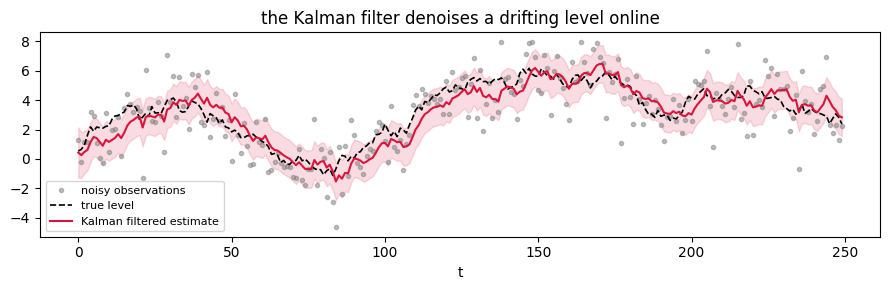

In [2]:
def kalman_filter(y, q, r, x0=0.0, P0=1.0):
    xf, Pf = [], []
    x, P = x0, P0
    for yt in y:
        x, P = x, P + q                          # predict
        Kt = P / (P + r)                          # Kalman gain
        x, P = x + Kt * (yt - x), (1 - Kt) * P    # update
        xf.append(x); Pf.append(P)
    return np.array(xf), np.array(Pf)

true_level = np.cumsum(rng.normal(0, 0.3, 250))      # the hidden random-walk level
y = true_level + rng.normal(0, 1.5, 250)             # noisy observations
xf, Pf = kalman_filter(y, q=0.09, r=2.25)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(y, '.', color='gray', alpha=0.5, label='noisy observations')
ax.plot(true_level, 'k--', lw=1.2, label='true level')
ax.plot(xf, color='crimson', lw=1.5, label='Kalman filtered estimate')
ax.fill_between(range(len(y)), xf - 2 * np.sqrt(Pf), xf + 2 * np.sqrt(Pf), color='crimson', alpha=0.15)
ax.set_xlabel('t'); ax.legend(fontsize=8); ax.set_title('the Kalman filter denoises a drifting level online')
plt.tight_layout(); plt.show()

## 2. Fitting it with mixle: filtering vs smoothing

We didn't know $q$ and $r$ above - we guessed. `LocalLevel().fit(series)` learns them by EM (each E-step runs the Kalman filter and its backward partner, the RTS smoother) and returns the smoothed state (using the whole series) with uncertainty. Compare filtered (online, lags at turns) vs smoothed (offline, sharper): the difference is exactly what future data buys you.


learned: level_sd=0.369  obs_sd=1.483


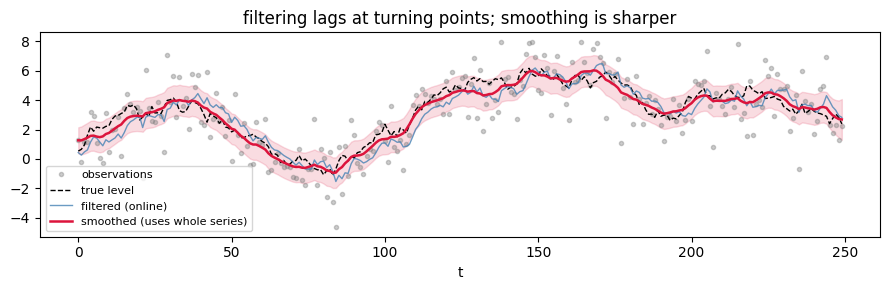

In [3]:
m = LocalLevel().fit(list(y))
print('learned: level_sd=%.3f  obs_sd=%.3f' % (m.params['level_sd'], m.params['obs_sd']))
smoothed = np.asarray(m.result.smoothed)
ssd = np.asarray(m.result.smoothed_sd)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(y, '.', color='gray', alpha=0.4, label='observations')
ax.plot(true_level, 'k--', lw=1.0, label='true level')
ax.plot(xf, color='steelblue', lw=1.0, alpha=0.8, label='filtered (online)')
ax.plot(smoothed, color='crimson', lw=1.8, label='smoothed (uses whole series)')
ax.fill_between(range(len(y)), smoothed - 2 * ssd, smoothed + 2 * ssd, color='crimson', alpha=0.15)
ax.set_xlabel('t'); ax.legend(fontsize=8); ax.set_title('filtering lags at turning points; smoothing is sharper')
plt.tight_layout(); plt.show()

## 3. AR(1): mean reversion, and forecasting

The local level has $\phi=1$ (a random walk that never returns). `AR1()` estimates the autoregressive coefficient $\phi$ instead: $|\phi|<1$ gives a mean-reverting state (shocks decay), the right model for many economic and physical series. The fitted state-space model also forecasts forward with growing uncertainty - honest about how the unknown future fans out.


AR(1) recovered phi=0.88 (true 0.85), obs_sd=0.48


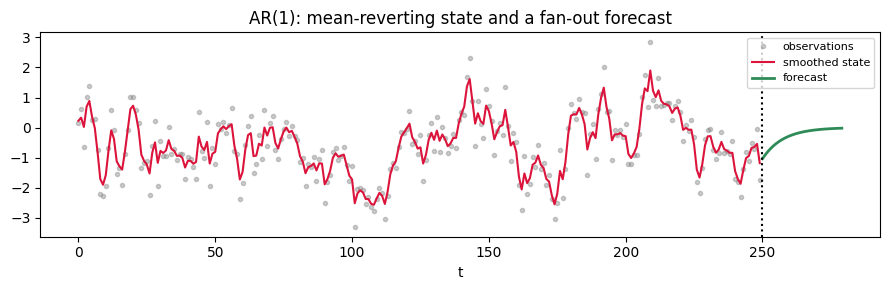

In [4]:
# mean-reverting truth: x_t = 0.85 x_{t-1} + noise, observed with noise
x = np.zeros(250)
for t in range(1, 250):
    x[t] = 0.85 * x[t - 1] + rng.normal(0, 0.6)
yr = x + rng.normal(0, 0.5, 250)
ar = AR1().fit(list(yr))
print('AR(1) recovered phi=%.2f (true 0.85), obs_sd=%.2f' % (ar.params['phi'], ar.params['obs_sd']))

fc = ar.result.forecast(30)                      # 30-step-ahead forecast with uncertainty
fmean = np.asarray(fc['mean'] if isinstance(fc, dict) else fc)
fsd = np.asarray(fc['sd']) if isinstance(fc, dict) and 'sd' in fc else None
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(yr, '.', color='gray', alpha=0.4, label='observations')
ax.plot(np.asarray(ar.result.smoothed), color='crimson', lw=1.5, label='smoothed state')
fx = np.arange(len(yr), len(yr) + len(fmean))
ax.plot(fx, fmean, color='seagreen', lw=2, label='forecast')
if fsd is not None:
    ax.fill_between(fx, fmean - 2 * fsd, fmean + 2 * fsd, color='seagreen', alpha=0.15)
ax.axvline(len(yr), color='k', ls=':'); ax.set_xlabel('t'); ax.legend(fontsize=8)
ax.set_title('AR(1): mean-reverting state and a fan-out forecast')
plt.tight_layout(); plt.show()

## Validate the filter with its innovations

A correctly specified Kalman filter produces white, unit-variance standardized innovations $\tilde e_t = (y_t - \hat y_{t|t-1})/\sqrt{S_t}$ - this is the standard consistency check (Bar-Shalom). If they are autocorrelated or have variance far from 1, the noise levels are wrong. We compute them from the learned `LocalLevel` parameters and check the three diagnostics.


In [5]:
q, r = m.params['level_sd'] ** 2, m.params['obs_sd'] ** 2
x_pred, P, innov = 0.0, 1.0, []
for yt in y:
    P = P + q                                           # predict step
    S = P + r                                           # innovation variance
    innov.append((yt - x_pred) / np.sqrt(S))
    Kt = P / S; x_pred = x_pred + Kt * (yt - x_pred); P = (1 - Kt) * P
innov = np.array(innov)
acf1 = np.corrcoef(innov[:-1], innov[1:])[0, 1]
print('standardized innovations:  mean=%.2f (want 0)   var=%.2f (want 1)   lag-1 autocorr=%.2f (want 0)' %
      (innov.mean(), innov.var(), acf1))
print('all three near target => the learned noise levels are consistent with the data.')

standardized innovations:  mean=0.03 (want 0)   var=1.00 (want 1)   lag-1 autocorr=-0.05 (want 0)
all three near target => the learned noise levels are consistent with the data.


## Illustration: the Kalman filter equals the exact batch posterior

For a local-level model we form the full joint Gaussian over the hidden states and observations, then
condition on all observations to get the exact posterior of the final state by linear algebra. The
recursive Kalman filter reproduces that mean and variance exactly, confirming it is the exact Bayesian
posterior, not an approximation.

In [6]:
rng = np.random.RandomState(0)
T = 25; q, r, P0 = 0.3, 0.5, 1.0                         # local level: x_t = x_{t-1}+w, y_t = x_t+v
x = np.cumsum(rng.normal(0, np.sqrt(q), T)); y = x + rng.normal(0, np.sqrt(r), T)
# recursive Kalman filter
xf, Pf = 0.0, P0
for t in range(T):
    xp, Pp = xf, Pf + q
    K = Pp / (Pp + r); xf = xp + K * (y[t] - xp); Pf = (1 - K) * Pp
# exact batch posterior: joint Gaussian of (x_{1:T}, y_{1:T}), condition on y
idx = np.arange(1, T + 1)
Cx = P0 + q * np.minimum(idx[:, None], idx[None, :])     # Cov(x_s, x_t) = P0 + q*min(s,t)
Cy = Cx + r * np.eye(T)                                  # y = x + independent noise
xb = (Cx[-1] @ np.linalg.solve(Cy, y))                   # E[x_T | y]
Pb = Cx[-1, -1] - Cx[-1] @ np.linalg.solve(Cy, Cx[-1])   # Var[x_T | y]
print('Kalman filter final state: mean = %.5f  variance = %.5f' % (xf, Pf))
print('exact batch posterior    : mean = %.5f  variance = %.5f' % (xb, Pb))
print('match: %s (the recursive filter is the exact Bayesian posterior)' % bool(np.isclose(xf, xb) and np.isclose(Pf, Pb)))

Kalman filter final state: mean = 5.62365  variance = 0.26533
exact batch posterior    : mean = 5.62365  variance = 0.26533
match: True (the recursive filter is the exact Bayesian posterior)


## References

- Kalman, R. E. (1960). A new approach to linear filtering and prediction problems (https://doi.org/10.1115/1.3662552). J. Basic Eng. 82(1), 35-45.
- Rauch, H. E., Tung, F. & Striebel, C. T. (1965). Maximum likelihood estimates of linear dynamic systems (https://doi.org/10.2514/3.3166). AIAA J. 3(8), 1445-1450. - the RTS smoother.
- Durbin, J. & Koopman, S. J. (2012). Time Series Analysis by State Space Methods, 2nd ed. Oxford University Press.
- Harvey, A. C. (1989). Forecasting, Structural Time Series Models and the Kalman Filter. Cambridge University Press.
- Särkkä, S. (2013). Bayesian Filtering and Smoothing (https://users.aalto.fi/~ssarkka/pub/cup_book_online_20131111.pdf). Cambridge University Press.


## Exercises and extensions

1. Filter and smoother from scratch. Implement the full Kalman filter and the RTS backward smoother (Rauch-Tung-Striebel); verify the filtered estimate at the final time equals the smoothed one there, and that the smoother's variances are everywhere ≤ the filter's. Reproduce the gain's predict/update interpretation.
2. EM for the noise variances. The local-level model has unknown $q$ (level noise) and $r$ (observation noise). Implement EM (E-step = Kalman/RTS, M-step = closed-form variance updates) to learn them, and compare to mixle's `LocalLevel().fit`; plot the likelihood surface in $(q, r)$ and discuss the signal-to-noise identifiability ridge.
3. Model selection among structural models. Fit local-level, AR(1)-plus-noise, and local-linear-trend models (Harvey; Durbin-Koopman) to a series and select among them by held-out one-step-ahead predictive likelihood; recover which generating process the data came from.
4. Forecast calibration and nonlinearity. Check that $h$-step-ahead forecast intervals have nominal coverage on held-out data; then take a nonlinear/non-Gaussian series and sketch why an extended/unscented Kalman filter or a particle filter is needed (Särkkä).
